# Revisión de la  mejor ejecución de PCA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull
from pathlib import Path

# Configuración opcional para asegurar gráficos nítidos en el notebook
%matplotlib inline

In [2]:
# 1. Definición del directorio actual y la raíz del proyecto
directorio_actual = Path.cwd().resolve()
PROJECT_ROOT = directorio_actual.parent

# Validación de seguridad del directorio de datos
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError(
        f"No se encontró la carpeta 'data' dentro de {PROJECT_ROOT}"
    )

# 2. Configuración de rutas específicas según la estructura del proyecto
DATASETS_DIR = PROJECT_ROOT / "data" / "processed" / "discretizaciones"
ruta_datasets = DATASETS_DIR / "interpolacion_50.parquet"

# 3. Carga del dataset original de interpolación
df_interpolacion_50 = pd.read_parquet(ruta_datasets)

# 4. Aislamiento de variables numéricas (curvas discretizadas en 50 dimensiones)
# Filtramos para asegurar que no se incluyan índices o columnas de texto en el PCA
X_original = df_interpolacion_50.select_dtypes(include=[np.number]).values

# 5. Selección de la muestra aleatoria de 1,000 estrellas (fijando semilla 42)
np.random.seed(42)
if X_original.shape[0] > 1000:
    indices_muestra = np.random.choice(X_original.shape[0], size=1000, replace=False)
    X_sample = X_original[indices_muestra]
else:
    X_sample = X_original

print(f"Dataset original cargado exitosamente desde: {ruta_datasets.name}")
print(f"Dimensiones del subconjunto de juguete para la prueba: {X_sample.shape}")


Dataset original cargado exitosamente desde: interpolacion_50.parquet
Dimensiones del subconjunto de juguete para la prueba: (1000, 50)


In [3]:
# 1. Inicializar el modelo PCA configurado para extraer 2 componentes principales
pca = PCA(n_components=2)

# 2. Ajustar el modelo y transformar la muestra al espacio reducido (1000, 50) -> (1000, 2)
X_pca = pca.fit_transform(X_sample)

# 3. Calcular el centroide geométrico (la media de los datos en PC1 y PC2)
centroide = np.mean(X_pca, axis=0)

# 4. Mostrar métrica de varianza explicada para el rigor del análisis
var_explicada = pca.explained_variance_ratio_
print(f"Dimensiones de la matriz transformada X_pca: {X_pca.shape}")
print(f"Varianza explicada por PC1: {var_explicada[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {var_explicada[1]*100:.2f}%")
print(f"Varianza total acumulada en 2D: {sum(var_explicada)*100:.2f}%")
print(f"Coordenadas del centroide en el espacio PCA: {centroide}")


Dimensiones de la matriz transformada X_pca: (1000, 2)
Varianza explicada por PC1: 99.52%
Varianza explicada por PC2: 0.28%
Varianza total acumulada en 2D: 99.80%
Coordenadas del centroide en el espacio PCA: [-1.7829894e-05 -1.2840032e-06]


In [4]:
# 1. Calcular la distancia euclidiana de cada punto (estrella) al centroide geométrico en 2D
# Se utiliza la norma lineal vectorizada para medir la distancia fila por fila
distancias_centroide = np.linalg.norm(X_pca - centroide, axis=1)

# 2. Ordenar los índices de menor a mayor distancia y extraer los 10 índices con los valores más altos
# argsort devuelve los índices posicionales de la muestra X_sample
indices_enfoque1 = np.argsort(distancias_centroide)[-10:]

print(f"Total de estrellas seleccionadas: {len(indices_enfoque1)}")
print(f"Índices posicionales de las 10 estrellas más lejanas al centroide:\n{indices_enfoque1}")


Total de estrellas seleccionadas: 10
Índices posicionales de las 10 estrellas más lejanas al centroide:
[301 936 735 406 263  70 219 785 183 215]


In [5]:
# 1. Encontrar los índices posicionales de los valores mínimos y máximos en el primer eje (PC1)
idx_min_pc1 = np.argmin(X_pca[:, 0])
idx_max_pc1 = np.argmax(X_pca[:, 0])

# 2. Encontrar los índices posicionales de los valores mínimos y máximos en el segundo eje (PC2)
idx_min_pc2 = np.argmin(X_pca[:, 1])
idx_max_pc2 = np.argmax(X_pca[:, 1])

# 3. Consolidar los índices en una lista utilizando 'set' para eliminar duplicados 
# (en caso de que una misma estrella sea el extremo en más de un eje)
indices_enfoque2 = list(set([idx_min_pc1, idx_max_pc1, idx_min_pc2, idx_max_pc2]))

print(f"Estrella extrema inferior en PC1 (Mínimo): {idx_min_pc1}")
print(f"Estrella extrema superior en PC1 (Máximo): {idx_max_pc1}")
print(f"Estrella extrema inferior en PC2 (Mínimo): {idx_min_pc2}")
print(f"Estrella extrema superior en PC2 (Máximo): {idx_max_pc2}")
print(f"\nTotal de estrellas únicas seleccionadas: {len(indices_enfoque2)}")
print(f"Índices consolidados para el Enfoque 2: {indices_enfoque2}")


Estrella extrema inferior en PC1 (Mínimo): 215
Estrella extrema superior en PC1 (Máximo): 977
Estrella extrema inferior en PC2 (Mínimo): 36
Estrella extrema superior en PC2 (Máximo): 336

Total de estrellas únicas seleccionadas: 4
Índices consolidados para el Enfoque 2: [np.int64(336), np.int64(977), np.int64(36), np.int64(215)]


In [6]:
# 1. Calcular la envoltura convexa (Convex Hull) sobre las dos dimensiones de PCA
# La función ConvexHull de SciPy analiza la geometría espacial y detecta la frontera
hull = ConvexHull(X_pca)

# 2. Extraer los índices de los puntos que forman los vértices del polígono exterior
# hull.vertices devuelve los índices posicionales ordenados de forma contrarreloj en la frontera
indices_enfoque3 = hull.vertices

print(f"Total de estrellas detectadas en la frontera exterior por Convex Hull: {len(indices_enfoque3)}")
print(f"Índices de los vértices seleccionados:\n{indices_enfoque3}")


Total de estrellas detectadas en la frontera exterior por Convex Hull: 14
Índices de los vértices seleccionados:
[441 977 310 336 240 377 179 215 183 406 936 579 691  36]


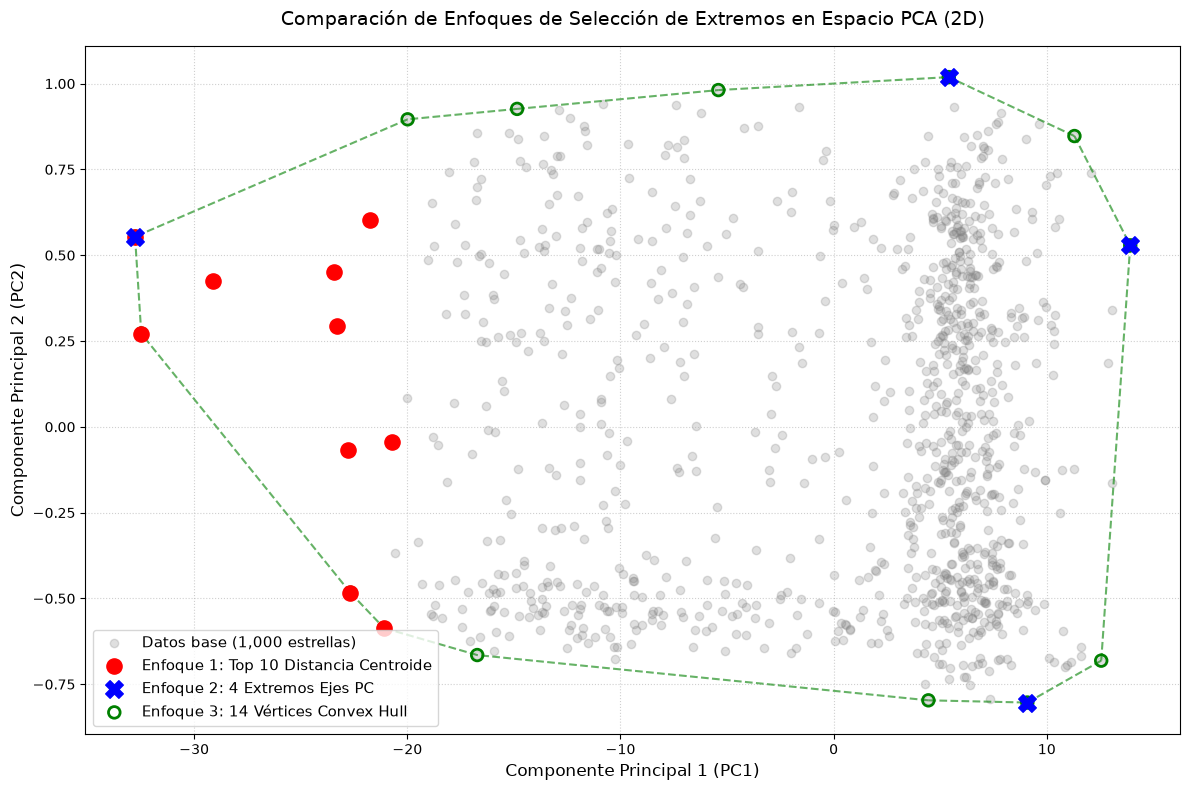

In [7]:
# 1. Configurar el tamaño y resolución del gráfico
plt.figure(figsize=(12, 8), dpi=100)

# 2. Dibujar toda la nube de datos base (las 1,000 curvas de luz de la muestra)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.25, color='gray', label='Datos base (1,000 estrellas)')

# 3. Dibujar las líneas punteadas que conectan los vértices del Convex Hull (Enfoque 3)
# Se itera sobre las aristas (simplices) calculadas por SciPy para cerrar el polígono
for simplex in hull.simplices:
    plt.plot(X_pca[simplex, 0], X_pca[simplex, 1], 'g--', alpha=0.6, linewidth=1.5)

# 4. Resaltar los puntos seleccionados por cada enfoque con diferentes marcadores y tamaños
plt.scatter(X_pca[indices_enfoque1, 0], X_pca[indices_enfoque1, 1], 
            color='red', s=120, zorder=3, label='Enfoque 1: Top 10 Distancia Centroide')

plt.scatter(X_pca[indices_enfoque2, 0], X_pca[indices_enfoque2, 1], 
            color='blue', s=160, marker='X', zorder=4, label='Enfoque 2: 4 Extremos Ejes PC')

plt.scatter(X_pca[indices_enfoque3, 0], X_pca[indices_enfoque3, 1], 
            color='green', s=70, facecolors='none', edgecolors='green', linewidth=2, zorder=2, 
            label='Enfoque 3: 14 Vértices Convex Hull')

# 5. Formatear ejes y etiquetas con rigor académico
plt.title('Comparación de Enfoques de Selección de Extremos en Espacio PCA (2D)', fontsize=14, pad=15)
plt.xlabel('Componente Principal 1 (PC1)', fontsize=12)
plt.ylabel('Componente Principal 2 (PC2)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# 6. Desplegar el gráfico en el notebook
plt.tight_layout()
plt.show()


### Informe Técnico: Evaluación de Métodos de Inicialización en Espacio PCA

#### 1. Métricas de Evaluación Utilizadas
* **Cobertura Geométrica Extrema:** Capacidad del método para capturar los límites reales de la distribución en todas las direcciones del espacio latente, evitando sesgos por densidad local.
* **Escalabilidad y Flexibilidad para $K$ Variable:** Viabilidad del conjunto seleccionado para abastecer un algoritmo posterior de selección ávida (como *Furthest Sum*) en un rango de $K \in [2, 10]$.

#### 2. Análisis de Comportamiento
* **Enfoque 1 (Distancia al Centroide):** **Descartado.** La alta densidad de curvas concentrada en el sector positivo de PC1 desplaza el centroide geométrico. Como consecuencia, las 10 curvas más distantes se ubican exclusivamente en la cola izquierda (región hiper-negativa de PC1). Esto introduce un sesgo de selección crítico, omitiendo la frontera de los datos densos.
* **Enfoque 2 (Extremos de Ejes PC):** **Descartado.** Proporciona únicamente 4 candidatos ortogonales. Presenta una sub-cobertura severa de la frontera diagonal y carece de la dimensionalidad necesaria para soportar experimentos donde el número de arquetipos sea mayor a 4 ($K > 4$).
* **Enfoque 3 (Convex Hull):** **Veredicto: Ganador.** Identifica de forma matemática y exacta las 14 estructuras limítrofes (vértices) que encierran el 100% de la muestra. Logra un balance perfecto entre las zonas de baja densidad (izquierda) y alta densidad (derecha).

#### 3. Conclusión Metodológica para el Pipeline de la Tesis
El subconjunto de 14 estrellas identificadas por el **Convex Hull en el espacio PCA** constituye el espacio de búsqueda óptimo. Al eliminar la masa central redundante de datos, este filtro regulariza el problema no convexo. El algoritmo posterior de **Furthest Sum** operará sobre estos 14 vértices para extraer de forma determinista y sin sesgos de densidad los $K$ arquetipos iniciales exactos (de 2 a 10) que maximicen la dispersión morfológica del catálogo.
